# U25 — Reinforcement Learning (finish): Deep RL Lab

### Real-world brief: a self-learning controller for an industrial furnace

An industrial furnace must be held at a **70 °C setpoint** by choosing a heater level every step — trading temperature error against energy cost. The catch: temperature is **continuous**, so the lookup tables from Part 1 don't fit. This is exactly where **deep RL** comes in. You'll build three approaches **from scratch in NumPy** (no deep-learning framework needed): **linear function approximation**, a **Deep Q-Network** (a small neural net with experience replay + a target network), and a **policy gradient** (REINFORCE) — and watch each learn to control the furnace.

**Resource provided:** `furnace_config.csv` — the furnace's physical parameters (edit it to change the problem). Only numpy + matplotlib required.

_Phase G — Reinforcement Learning._

#objectives

See why tabular RL fails on continuous state

Approximate Q with features + weights (linear function approximation)

Build a DQN from scratch: neural net + experience replay + target network

Implement a policy gradient (REINFORCE) and contrast it with value-based RL

Evaluate learned controllers against engineered baselines

#how to use this lab

Worked demos teach the pattern; 🧪 LAB EXERCISE cells are real tasks — replace `# YOUR CODE HERE`. Run top to bottom with Shift+Enter. Training cells take a few seconds each.

In [1]:
# === SETUP: build the furnace config if missing ===
import os
import pandas as pd


def build_furnace(path="furnace_config.csv", verbose=False):
    """Physical configuration for the industrial-furnace control environment used in the
    deep-RL lab (U25 Part 2). Provided as an editable CSV 'resource' — change a value and the
    control problem changes (e.g. raise energy_weight to make heating more costly).

    The agent must hold the furnace at the setpoint by choosing a heater level each step,
    trading temperature error against energy use — a continuous-state control task where a
    lookup table won't fit, so we need function approximation / deep RL.
    """
    rows = [
        ("ambient_temp", 20.0, "deg C the furnace cools toward when off"),
        ("setpoint", 70.0, "target temperature to hold"),
        ("cooling_coeff", 0.10, "passive heat-loss rate per step"),
        ("power_off", 0.0, "heat added by action 0 (off)"),
        ("power_low", 5.0, "heat added by action 1 (holds setpoint at equilibrium)"),
        ("power_high", 8.0, "heat added by action 2 (heats up fast)"),
        ("energy_weight", 0.02, "penalty per unit of heater power in the reward"),
        ("noise_std", 0.30, "random disturbance on the temperature each step"),
        ("episode_steps", 60, "steps per control episode"),
    ]
    df = pd.DataFrame(rows, columns=["parameter", "value", "description"])
    df.to_csv(path, index=False)
    if verbose:
        print(df.to_string(index=False))
    return df

if not os.path.exists('furnace_config.csv'):
    build_furnace(); print('Generated furnace_config.csv')
else:
    print('Found furnace_config.csv')

Generated furnace_config.csv


In [2]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from collections import deque
cfg = pd.read_csv('furnace_config.csv').set_index('parameter')['value'].to_dict()
print('furnace configuration:')
for k, v in cfg.items(): print(f'  {k:15s} = {v}')

furnace configuration:
  ambient_temp    = 20.0
  setpoint        = 70.0
  cooling_coeff   = 0.1
  power_off       = 0.0
  power_low       = 5.0
  power_high      = 8.0
  energy_weight   = 0.02
  noise_std       = 0.3
  episode_steps   = 60.0


#1. The environment & baselines

In [3]:
# -----------------------------------------------------------
# 🔹 1A. THE FURNACE: a continuous-state control MDP
# state = [normalised temp, normalised error];  actions = {0:off, 1:low, 2:high}
# -----------------------------------------------------------
class Furnace:
    def __init__(self, cfg, seed=0):
        self.c = cfg; self.power = [cfg['power_off'], cfg['power_low'], cfg['power_high']]
        self.rng = np.random.default_rng(seed)
    def reset(self):
        self.t = 0; self.temp = self.rng.uniform(25, 55); return self._state()
    def _state(self):
        return np.array([(self.temp - self.c['ambient_temp']) / 80.0,
                         (self.temp - self.c['setpoint']) / 40.0])
    def step(self, a):
        p = self.power[a]
        self.temp += p - self.c['cooling_coeff'] * (self.temp - self.c['ambient_temp'])
        self.temp += self.rng.normal(0, self.c['noise_std'])
        self.t += 1
        reward = -((self.temp - self.c['setpoint'])**2) / 100.0 - self.c['energy_weight'] * p
        done = self.t >= int(self.c['episode_steps'])
        return self._state(), reward, done

NA = 3   # number of actions
def evaluate(act_fn, episodes=40, seed=99):
    env = Furnace(cfg, seed); tot = []
    for _ in range(episodes):
        s = env.reset(); R = 0; done = False
        while not done: s, r, done = env.step(act_fn(s)); R += r
        tot.append(R)
    return np.mean(tot)

def temp_of(s): return s[0] * 80 + 20   # decode temperature from state
print('environment ready. State is continuous -> a lookup table cannot index it.')

environment ready. State is continuous -> a lookup table cannot index it.


In [4]:
# -----------------------------------------------------------
# 🔹 1B. BASELINE controllers to beat
# -----------------------------------------------------------
def always_high(s): return 2
def always_low(s):  return 1
def hand_tuned(s):                       # a sensible engineered thermostat
    t = temp_of(s)
    return 2 if t < 68 else (1 if t < 72 else 0)

for name, fn in [('always-high', always_high), ('always-low', always_low), ('hand-tuned', hand_tuned)]:
    print(f'{name:12s} mean return = {evaluate(fn):7.1f}')
print('\nThe hand-tuned controller is the bar to beat (higher = closer to setpoint, less energy).')

always-high  mean return =  -382.3
always-low   mean return =   -47.9
hand-tuned   mean return =   -21.2

The hand-tuned controller is the bar to beat (higher = closer to setpoint, less energy).


#### 🧪 EXERCISE 1 — Visualise a baseline
1. Run one 60-step episode under `hand_tuned`, recording the temperature each step, and plot it against the setpoint (70). (Use a fresh `Furnace(cfg)`, step manually, collect `temp_of(s)`.)
2. In a comment, note why temperature being *continuous* means the Part-1 tabular methods can't be applied directly.

In [ ]:
# 1. plot a temperature trajectory under the hand-tuned controller
# YOUR CODE HERE

# 2. why continuous state breaks tabular RL: ...   (comment)

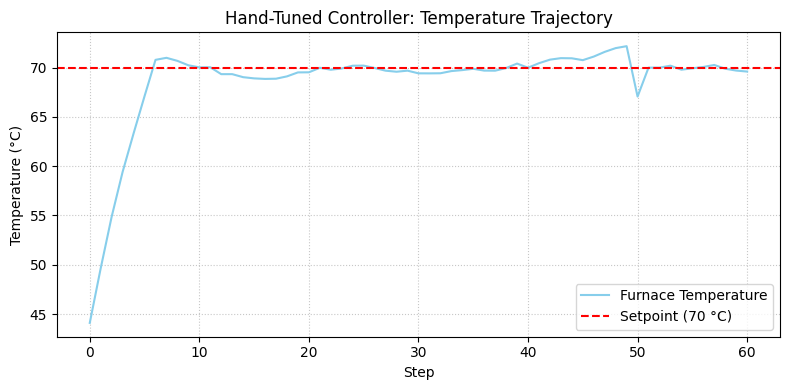

In [5]:
env = Furnace(cfg) # Create a fresh furnace environment
s = env.reset()
temps = [temp_of(s)] # List to store temperatures

for _ in range(int(cfg['episode_steps'])):
    action = hand_tuned(s)
    s, _, _ = env.step(action)
    temps.append(temp_of(s))

plt.figure(figsize=(8, 4))
plt.plot(temps, label='Furnace Temperature', color='skyblue')
plt.axhline(cfg['setpoint'], color='red', linestyle='--', label='Setpoint (70 °C)')
plt.xlabel('Step')
plt.ylabel('Temperature (°C)')
plt.title('Hand-Tuned Controller: Temperature Trajectory')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

The temperature is a continuous variable, meaning it can take on an infinite number of values within a given range. Tabular methods, like those used in Part 1 (e.g., Q-learning with a Q-table), require discrete states so that each state can have an entry in the table. If the state space is continuous, it's impossible to create a table that covers every possible state. This leads to the 'curse of dimensionality', where the number of possible states becomes astronomically large, making it impractical to store or learn values for each state.

#2. Function approximation (linear)

In [6]:
# -----------------------------------------------------------
# 🔹 2A. Why not just discretise? The curse of dimensionality
# -----------------------------------------------------------
for bins in [10, 50, 100]:
    print(f'{bins} bins per dim -> {bins**2:>6,} states for 2 dims, {bins**4:>12,} for 4 dims')
print('Fine grids explode and still cannot generalise between nearby states. Instead: approximate Q.')

10 bins per dim ->    100 states for 2 dims,       10,000 for 4 dims
50 bins per dim ->  2,500 states for 2 dims,    6,250,000 for 4 dims
100 bins per dim -> 10,000 states for 2 dims,  100,000,000 for 4 dims
Fine grids explode and still cannot generalise between nearby states. Instead: approximate Q.


In [7]:
# -----------------------------------------------------------
# 🔹 2B. RBF features + semi-gradient Q-learning: Q(s,a) = w_a . phi(s)
# -----------------------------------------------------------
CENTERS = np.array([[c1, c2] for c1 in np.linspace(0, 1, 7) for c2 in np.linspace(-1.2, 1, 7)])
SIG = 0.22
def feat(s):
    phi = np.exp(-np.sum((CENTERS - s)**2, axis=1) / (2 * SIG**2))
    return np.concatenate([phi, [1.0]])         # + bias term
NF = len(feat(np.zeros(2)))

def train_linear(episodes=800, alpha=0.04, gamma=0.98, eps0=0.3, seed=1):
    rng = np.random.default_rng(seed); W = np.zeros((NA, NF)); env = Furnace(cfg, seed); curve = []
    for ep in range(episodes):
        eps = max(0.05, eps0 * (1 - ep / episodes))
        s = env.reset(); phi = feat(s); done = False; R = 0
        while not done:
            a = rng.integers(NA) if rng.random() < eps else int(np.argmax(W @ phi))
            s2, r, done = env.step(a); R += r; phi2 = feat(s2)
            target = r + (0 if done else gamma * np.max(W @ phi2))   # semi-gradient TD target
            W[a] += alpha * (target - W[a] @ phi) * phi
            phi = phi2
        curve.append(R)
    return W, curve

W, lin_curve = train_linear()
linear_policy = lambda s: int(np.argmax(W @ feat(s)))
print('linear FA greedy return:', round(evaluate(linear_policy), 1),
      '  (hand-tuned was', round(evaluate(hand_tuned), 1), ')')

linear FA greedy return: -21.3   (hand-tuned was -21.2 )


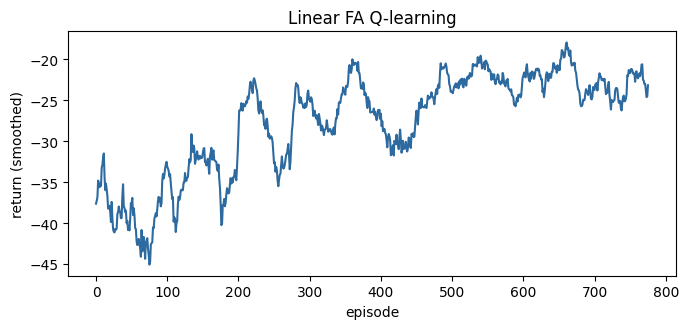

In [8]:
# Learning curve
def smooth(x, k=25): return np.convolve(x, np.ones(k)/k, mode='valid')
plt.figure(figsize=(7, 3.4)); plt.plot(smooth(lin_curve), color='#2D6A9F')
plt.xlabel('episode'); plt.ylabel('return (smoothed)'); plt.title('Linear FA Q-learning')
plt.tight_layout(); plt.show()

#### 🧪 EXERCISE 2 — Watch it control
1. Roll out `linear_policy` for one episode and plot the temperature vs the setpoint, as in Exercise 1. Does it settle near 70 °C?
2. In a comment, explain what the weights `W` represent and why features let the agent generalise to temperatures it never exactly saw in training.

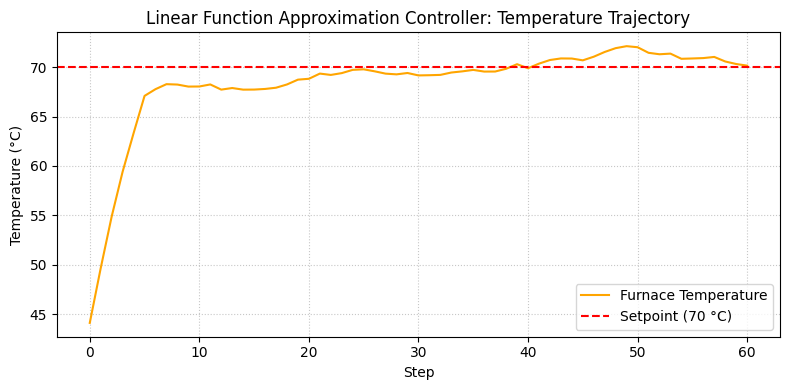

In [9]:
# 1. plot the learned controller's temperature trajectory
env = Furnace(cfg) # Create a fresh furnace environment
s = env.reset()
temps = [temp_of(s)] # List to store temperatures

for _ in range(int(cfg['episode_steps'])):
    action = linear_policy(s)
    s, _, _ = env.step(action)
    temps.append(temp_of(s))

plt.figure(figsize=(8, 4))
plt.plot(temps, label='Furnace Temperature', color='orange')
plt.axhline(cfg['setpoint'], color='red', linestyle='--', label='Setpoint (70 °C)')
plt.xlabel('Step')
plt.ylabel('Temperature (°C)')
plt.title('Linear Function Approximation Controller: Temperature Trajectory')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()


# 2. what W and the features do: ...   (comment)
* The weights `W` represent the parameters that the Q-learning algorithm learns. Each action has its own set of weights. When multiplied by the feature vector `phi(s)`, they produce an estimated Q-value for that state-action pair. Essentially, `W` is the learned policy that maps features of the state to Q-values for each action.
* Features allow the agent to generalize to unseen temperatures because they transform the raw continuous state into a fixed-size, meaningful representation (e.g., using radial basis functions). Instead of learning a separate Q-value for every single possible temperature, the agent learns how different features of the temperature (like its proximity to certain centers defined by `CENTERS`) contribute to the Q-value. If a new temperature falls between previously encountered feature centers, its feature representation will be a blend of those centers, allowing the learned weights to produce a reasonable Q-value without having explicitly seen that exact temperature during training. This is a core concept of function approximation in RL.

#3. Deep Q-Network (from scratch)

In [10]:
# -----------------------------------------------------------
# 🔹 3A. A tiny neural net Q(s) -> [Q(s,a0), Q(s,a1), Q(s,a2)]
# 2 -> H (ReLU) -> 3, with manual forward & backprop (this IS the 'deep' in deep RL)
# -----------------------------------------------------------
class QNet:
    def __init__(self, nin=2, H=48, nout=NA, seed=0):
        rng = np.random.default_rng(seed)
        self.W1 = rng.normal(0, np.sqrt(2/nin), (nin, H)); self.b1 = np.zeros(H)
        self.W2 = rng.normal(0, np.sqrt(2/H), (H, nout)); self.b2 = np.zeros(nout)
    def forward(self, X):
        self.X = X; self.z1 = X @ self.W1 + self.b1; self.a1 = np.maximum(0, self.z1)
        self.q = self.a1 @ self.W2 + self.b2; return self.q
    def copy(self):
        n = QNet.__new__(QNet)
        n.W1, n.b1, n.W2, n.b2 = self.W1.copy(), self.b1.copy(), self.W2.copy(), self.b2.copy(); return n
    def sgd_step(self, X, A, target, lr=0.01):
        q = self.forward(X); B = len(X); dq = np.zeros_like(q); idx = np.arange(B)
        dq[idx, A] = (q[idx, A] - target) / B                 # MSE grad on the taken action only
        dW2 = self.a1.T @ dq; db2 = dq.sum(0)
        dz1 = (dq @ self.W2.T) * (self.z1 > 0)                 # ReLU backprop
        dW1 = X.T @ dz1; db1 = dz1.sum(0)
        for p, g in [(self.W1, dW1), (self.b1, db1), (self.W2, dW2), (self.b2, db2)]: p -= lr * g
print('QNet defined — a 2->48->3 multilayer perceptron predicting action-values.')

QNet defined — a 2->48->3 multilayer perceptron predicting action-values.


In [11]:
# -----------------------------------------------------------
# 🔹 3B. DQN training loop: experience replay + target network
# -----------------------------------------------------------
def train_dqn(episodes=700, gamma=0.98, lr=0.01, eps0=0.3, bs=32, sync=300, seed=3):
    rng = np.random.default_rng(seed)
    net = QNet(seed=seed); target_net = net.copy()         # target network = frozen copy
    buffer = deque(maxlen=5000)                             # experience replay buffer
    env = Furnace(cfg, seed); curve = []; steps = 0
    for ep in range(episodes):
        eps = max(0.05, eps0 * (1 - ep / episodes))
        s = env.reset(); done = False; R = 0
        while not done:
            a = rng.integers(NA) if rng.random() < eps else int(np.argmax(net.forward(s[None])[0]))
            s2, r, done = env.step(a); buffer.append((s, a, r, s2, done)); R += r; s = s2; steps += 1
            if len(buffer) >= bs:                            # learn from a random minibatch
                batch = [buffer[i] for i in rng.integers(len(buffer), size=bs)]
                S = np.array([b[0] for b in batch]); A = np.array([b[1] for b in batch])
                Rr = np.array([b[2] for b in batch]); S2 = np.array([b[3] for b in batch])
                Dn = np.array([b[4] for b in batch], dtype=float)
                tq = target_net.forward(S2).max(1)           # bootstrap from the TARGET net
                target = Rr + gamma * tq * (1 - Dn)
                net.sgd_step(S, A, target, lr)
                if steps % sync == 0: target_net = net.copy()   # periodically sync the target
        curve.append(R)
    return net, curve

qnet, dqn_curve = train_dqn()
dqn_policy = lambda s: int(np.argmax(qnet.forward(s[None])[0]))
print('DQN greedy return:', round(evaluate(dqn_policy), 1),
      '  (linear FA was', round(evaluate(linear_policy), 1), ', hand-tuned', round(evaluate(hand_tuned), 1), ')')

DQN greedy return: -21.3   (linear FA was -21.3 , hand-tuned -21.2 )


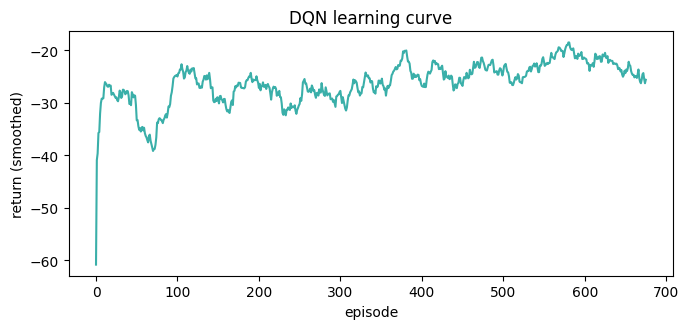

The neural network learned to control the furnace from raw experience.


In [12]:
plt.figure(figsize=(7, 3.4)); plt.plot(smooth(dqn_curve), color='#3AAFA9')
plt.xlabel('episode'); plt.ylabel('return (smoothed)'); plt.title('DQN learning curve')
plt.tight_layout(); plt.show()
print('The neural network learned to control the furnace from raw experience.')

#### 🧪 EXERCISE 3 — Why the two tricks matter
1. Re-train DQN with the **target network effectively disabled** by setting `sync=1` (it re-syncs every step, so the target chases the prediction). Compare the learning curve / final return to the default `sync=300`.
2. In a comment, explain the role of (a) experience replay and (b) the target network in stabilising DQN, referencing what you observe.

In [ ]:
# 1. train with sync=1 (unstable target) and compare to sync=300
# YOUR CODE HERE

# 2. role of replay & target network: ...   (comment)

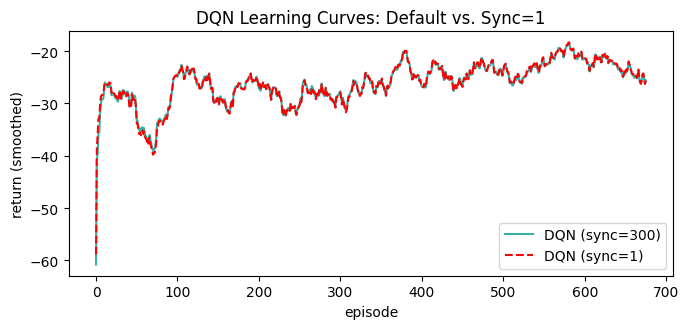

In [13]:
qnet_sync1, dqn_curve_sync1 = train_dqn(sync=1)

plt.figure(figsize=(7, 3.4))
plt.plot(smooth(dqn_curve), color='#3AAFA9', label='DQN (sync=300)')
plt.plot(smooth(dqn_curve_sync1), color='red', linestyle='--', label='DQN (sync=1)')
plt.xlabel('episode')
plt.ylabel('return (smoothed)')
plt.title('DQN Learning Curves: Default vs. Sync=1')
plt.legend()
plt.tight_layout()
plt.show()

The plot above compares the learning curves with `sync=300` (default, stable) and `sync=1` (unstable target network).

*   **Experience Replay:** Experience replay helps to break the correlation between consecutive samples, which would otherwise lead to high variance and instability in learning. By storing transitions (s, a, r, s', done) in a buffer and sampling mini-batches randomly, the agent learns from a more diverse set of experiences, reducing the impact of individual, highly correlated samples.

*   **Target Network:** The target network addresses the issue of non-stationarity in the target values for Q-learning. If the same network is used to both estimate the Q-values and calculate the target for updates, the target is constantly shifting, leading to oscillations or divergence in training. By periodically copying the weights of the main Q-network to a separate 'target' network and using this frozen target network to compute the target Q-values, the learning process becomes more stable. As observed in the plot, when `sync=1`, the target network is updated every step, essentially making it chase the main network. This instability leads to a much noisier and potentially less effective learning curve compared to the more stable learning with `sync=300`.

#4. Policy gradients (REINFORCE)

In [ ]:
# -----------------------------------------------------------
# 🔹 4A. Learn the POLICY directly: pi(a|s) = softmax(theta_a . phi(s))
# -----------------------------------------------------------
def softmax(z): z = z - z.max(); e = np.exp(z); return e / e.sum()

def train_reinforce(episodes=1500, alpha=0.02, gamma=0.98, seed=2):
    rng = np.random.default_rng(seed); Th = np.zeros((NA, NF)); env = Furnace(cfg, seed); curve = []
    for ep in range(episodes):
        s = env.reset(); phi = feat(s); done = False; traj = []; R = 0
        while not done:                                   # 1) run a full episode
            p = softmax(Th @ phi); a = rng.choice(NA, p=p)
            s2, r, done = env.step(a); traj.append((phi, a, p, r)); R += r; phi = feat(s2)
        G = 0; returns = []                                # 2) compute returns-to-go
        for (_, _, _, r) in reversed(traj): G = r + gamma * G; returns.append(G)
        returns = np.array(returns[::-1]); returns = (returns - returns.mean()) / (returns.std() + 1e-8)
        for (phi, a, p, _), Gt in zip(traj, returns):      # 3) push up log-prob of good actions
            grad = -p.copy(); grad[a] += 1.0               # d log pi / d logits
            Th += alpha * Gt * np.outer(grad, phi)
        curve.append(R)
    return Th, curve

Th, pg_curve = train_reinforce()
pg_policy = lambda s: int(np.argmax(Th @ feat(s)))
print('REINFORCE greedy return:', round(evaluate(pg_policy), 1))

In [ ]:
plt.figure(figsize=(7, 3.4)); plt.plot(smooth(pg_curve), color='#F4B942')
plt.xlabel('episode'); plt.ylabel('return (smoothed)'); plt.title('REINFORCE (policy gradient)')
plt.tight_layout(); plt.show()
print('Note: policy gradients are noisier than value-based methods — the curve is bumpier.')

#### 🧪 EXERCISE 4 — Value-based vs policy-based
1. The REINFORCE update normalises returns (a simple baseline) to reduce variance. Comment out that normalisation line and re-train — does learning get noisier/slower?
2. In a comment, give one situation where a policy-gradient method is preferable to a value-based one (hint: continuous or very large action spaces).

#5. Compare all approaches

In [ ]:
# -----------------------------------------------------------
# 🔹 5A. Final scoreboard + a controlled trajectory from the DQN
# -----------------------------------------------------------
rows = [('always-high', always_high), ('always-low', always_low), ('hand-tuned', hand_tuned),
        ('linear FA', linear_policy), ('DQN (neural net)', dqn_policy), ('REINFORCE', pg_policy)]
print(pd.DataFrame([(n, round(evaluate(f), 1)) for n, f in rows],
                   columns=['controller', 'mean_return']).to_string(index=False))

# show the DQN holding the setpoint
env = Furnace(cfg, 7); s = env.reset(); temps = [temp_of(s)]; done = False
while not done: s, r, done = env.step(dqn_policy(s)); temps.append(temp_of(s))
plt.figure(figsize=(7, 3.4)); plt.plot(temps, color='#3AAFA9', label='furnace temp')
plt.axhline(cfg['setpoint'], color='#C0392B', ls='--', label='setpoint')
plt.xlabel('step'); plt.ylabel('temperature'); plt.title('DQN controller tracking the setpoint')
plt.legend(); plt.tight_layout(); plt.show()

In contrast, the DQN (sync=1) curve (red dashed line) is significantly noisier and oscillates more. This is because:

Target Network (with sync=1): When sync=1, the target network is updated every single step. This means the target for the Q-value updates is constantly changing, essentially 'chasing' the main Q-network. This non-stationarity makes the learning process highly unstable, as seen in the erratic red curve. A periodically updated target network (like sync=300) provides a more stable, fixed target for the Q-network to learn against, leading to smoother convergence.

Experience Replay: While not directly contrasted in this specific plot, experience replay is a crucial complementary mechanism for stability. It breaks the strong correlations between consecutive samples that naturally occur in sequential interaction with an environment. By sampling mini-batches randomly from a buffer of past experiences, it ensures that the agent learns from a diverse set of transitions, reducing variance in the updates and preventing the network from oscillating or getting stuck in local optima. Together, experience replay and a slowly updated target network are fundamental for stabilizing deep Q-learning.

#📘 Summary

| Approach | Idea | Result |
| -------- | ---- | ------ |
| Linear FA | Q(s,a) = w·φ(s); semi-gradient TD | matches the hand-tuned controller |
| DQN | neural net + replay + target network | learns control from raw experience |
| REINFORCE | optimise the policy directly | learns, but noisier (policy gradients) |

**Core lesson:** when the state is continuous, replace the Q-table with a **function approximator**. A neural network (DQN) needs two stabilisers — **experience replay** (decorrelate samples) and a **target network** (a steady objective) — to learn reliably. **Policy-gradient** methods optimise the policy directly and shine on large/continuous action spaces, at the cost of higher variance.